<a href="https://colab.research.google.com/github/allatop/networks/blob/main/_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации**



## **Задание №1. Обучение модели ИНС для решения задачи регрессии**



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [ ]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

print(f"X shape: {X.shape}, y shape: {y.shape}")

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1869143222.py:5: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


X shape: (506, 13), y shape: (506,)


#### 1.2. Проектируем архитектуру для этой задачи

In [ ]:
from tensorflow.keras.layers import  Dense
from tensorflow.keras.models import Sequential

model = Sequential([
    Input(shape=(13,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

#### 1.4. Обучаем модель ИНС

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 597.0149 - mae: 22.4867 - val_loss: 508.9192 - val_mae: 21.1148
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 547.4501 - mae: 21.4727 - val_loss: 467.7531 - val_mae: 20.1820
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 479.5767 - mae: 20.1433 - val_loss: 423.1018 - val_mae: 19.1079
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 456.5555 - mae: 19.4232 - val_loss: 370.7692 - val_mae: 17.7757
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 391.3253 - mae: 18.0576 - val_loss: 311.4407 - val_mae: 16.1309
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 312.4130 - mae: 15.8455 - val_loss: 249.9853 - val_mae: 14.1770
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 248.6758 - mae: 13.5323 - val_loss: 188.7846 - val_mae: 11.9757
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 185.2585 - mae: 11.5655 - val_loss: 136.3233 - val_mae: 9.8204
Epoch 9/1

#### 1.6. Делаем предсказания на тестовых данных

In [ ]:
predictions = model.predict(X_test_scaled, verbose=0)

#### 1.7. Вычисляем метрику качества на тестовых данных

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ")
print(f"MSE (Среднеквадратичная ошибка): {mse:.2f}")
print(f"MAE (Средняя абсолютная ошибка): {mae:.2f}")
print(f"R2 (Коэффициент детерминации):   {r2:.3f}")
print(f"Средняя ошибка предсказания: ~${mae*1000:.0f}")

МЕТРИКИ КАЧЕСТВА МОДЕЛИ
MSE (Среднеквадратичная ошибка): 12.70
MAE (Средняя абсолютная ошибка): 2.44
R2 (Коэффициент детерминации):   0.827
Средняя ошибка предсказания: ~$2441


#### 1.8. Строим график обучения

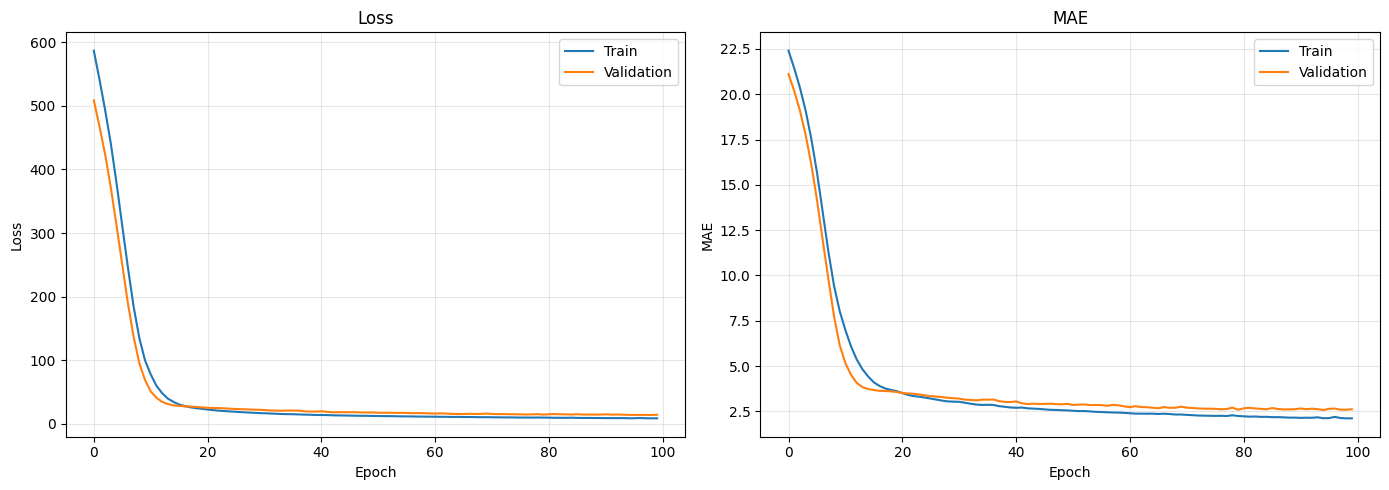

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('MAE')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [ ]:

print("ПРОВЕРКА МОДЕЛИ НА СЛУЧАЙНЫХ ПРИМЕРАХ")


for i in range(5):
    idx = np.random.randint(0, len(X_test_scaled))
    pred = model.predict(X_test_scaled[idx:idx+1], verbose=0)[0][0]
    actual = y_test[idx]
    error = abs(pred - actual)

    print(f"\nПример #{i+1}:")
    print(f"  Предсказано: ${pred*1000:.2f}")
    print(f"  Фактическое: ${actual*1000:.2f}")
    print(f"  Ошибка: ${error*1000:.2f} ({error/actual*100:.1f}%)")

ПРОВЕРКА МОДЕЛИ НА СЛУЧАЙНЫХ ПРИМЕРАХ

Пример #1:
  Предсказано: $12226.05
  Фактическое: $14900.00
  Ошибка: $2673.95 (17.9%)

Пример #2:
  Предсказано: $19351.27
  Фактическое: $18500.00
  Ошибка: $851.27 (4.6%)

Пример #3:
  Предсказано: $18940.72
  Фактическое: $18900.00
  Ошибка: $40.72 (0.2%)

Пример #4:
  Предсказано: $22995.98
  Фактическое: $22400.00
  Ошибка: $595.98 (2.7%)

Пример #5:
  Предсказано: $14701.19
  Фактическое: $16400.00
  Ошибка: $1698.81 (10.4%)


#### 2. Проверка обученной модели пользовательскими данными

In [ ]:
# Ваш код

## **Задание №2.Обучение модели ИНС для решения задачи классификации**



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [ ]:
# Импортируем LabelBinarizer для преобразования текстовых меток в векторы
# (например, "кошка" -> [1, 0, 0], "собака" -> [0, 1, 0], "панда" -> [0, 0, 1])
from sklearn.preprocessing import LabelBinarizer

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем classification_report для оценки качества классификации
from sklearn.metrics import classification_report

# Импортируем Sequential для создания последовательной модели нейронной сети
from keras.models import Sequential

# Импортируем Dense для создания плотных слоев нейронной сети
from keras.layers import Dense

# Импортируем SGD и Adam для оптимизации обучения нейронной сети
from keras.optimizers import SGD, Adam

# Импортируем paths из imutils для удобной работы с путями к изображениям
from imutils import paths

# Импортируем pyplot из matplotlib для визуализации данных
import matplotlib.pyplot as plt

# Импортируем numpy для работы с массивами данных
import numpy as np

# Импортируем random для генерации случайных чисел
import random

# Импортируем pickle для сериализации и десериализации данных
import pickle

# Импортируем cv2 для работы с изображениями
import cv2

# Импортируем os для работы с файловой системой
import os

# Импортируем cv2_imshow из google.colab.patches для отображения изображений в Colab
from google.colab.patches import cv2_imshow

### 2. Загружаем набор данных:

In [ ]:
# Ваш код

### 3. Указываем путь к набору данных:

In [ ]:
# Ваш код

### 4. Загружаем набор данных и формируем общую выборку:

In [ ]:
# Ваш код

#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [ ]:
# Ваш код

#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [ ]:
# Ваш код

### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [ ]:
# Ваш код

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [ ]:
# Ваш код

#### 5.3. Компилируем модель:

In [ ]:
# Ваш код

### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [ ]:
# Ваш код

#### 6.2. Запустим процесс обучения модели:

In [ ]:
# Ваш код

#### 6.3. Загружаем лучшую модель:

In [ ]:
# Ваш код

### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [ ]:
# Ваш код

#### 7.2. Выведем матрицу ошибок

In [ ]:
# Ваш код

#### 7.3. Отобразим график обучения

In [ ]:
# Ваш код

### 8. Сохранение модели и меток классов:

In [ ]:
# Ваш код

### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [ ]:
# Ваш код

#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [ ]:
# Ваш код

#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [ ]:
# Ваш код

### 10. Визуализируем интерфейс и произведем классификацию:

In [ ]:
# Ваш код